In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shahedurrahmanrafin/capstone-csv-2nd/Dataset of Diabetes .csv
/kaggle/input/datasets/shahedurrahmanrafin/capstone-image/Augmented Dataset/Healthy/Healthy453.jpg
/kaggle/input/datasets/shahedurrahmanrafin/capstone-image/Augmented Dataset/Healthy/Healthy1813.jpg
/kaggle/input/datasets/shahedurrahmanrafin/capstone-image/Augmented Dataset/Healthy/Healthy2574.jpg
/kaggle/input/datasets/shahedurrahmanrafin/capstone-image/Augmented Dataset/Healthy/Healthy2492.jpg
/kaggle/input/datasets/shahedurrahmanrafin/capstone-image/Augmented Dataset/Healthy/Healthy1025.jpg
/kaggle/input/datasets/shahedurrahmanrafin/capstone-image/Augmented Dataset/Healthy/Healthy436.jpg
/kaggle/input/datasets/shahedurrahmanrafin/capstone-image/Augmented Dataset/Healthy/Healthy236.jpg
/kaggle/input/datasets/shahedurrahmanrafin/capstone-image/Augmented Dataset/Healthy/Healthy661.jpg
/kaggle/input/datasets/shahedurrahmanrafin/capstone-image/Augmented Dataset/Healthy/Healthy200.jpg
/kaggle/input/datase

# =========================
# 1. IMPORTS
# =========================

In [3]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.combine import SMOTETomek

from catboost import CatBoostClassifier

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-04-10 13:24:30.094676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775827470.292813      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775827470.349704      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775827470.843085      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775827470.843126      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775827470.843129      55 computation_placer.cc:177] computation placer alr

# =========================
# 2. LOAD CLINICAL DATA
# =========================

In [4]:
file_path = "/kaggle/input/datasets/shahedurrahmanrafin/capstone-csv-2nd/Dataset of Diabetes .csv"

df = pd.read_csv(file_path)

print("Dataset loaded:", df.shape)

Dataset loaded: (1000, 14)


In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)

# Show result
print(df_encoded.head())
print(df_encoded.columns)


    ID  No_Pation  AGE  Urea  Cr  HbA1c  Chol   TG  HDL  LDL  VLDL   BMI  \
0  502      17975   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0   
1  735      34221   26   4.5  62    4.9   3.7  1.4  1.1  2.1   0.6  23.0   
2  420      47975   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0   
3  680      87656   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0   
4  504      34223   33   7.1  46    4.9   4.9  1.0  0.8  2.0   0.4  21.0   

   Gender_M  Gender_f  CLASS_N   CLASS_P  CLASS_Y  CLASS_Y   
0     False     False     False    False    False     False  
1      True     False     False    False    False     False  
2     False     False     False    False    False     False  
3     False     False     False    False    False     False  
4      True     False     False    False    False     False  
Index(['ID', 'No_Pation', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL',
       'LDL', 'VLDL', 'BMI', 'Gender_M', 'Gender_f', 'CLASS_N ', 'CLASS_P',
       'CLASS_Y', 

In [6]:
df_encoded.columns = df_encoded.columns.str.strip()
df_encoded = df_encoded.loc[:, ~df_encoded.columns.duplicated()]

# =========================
# 3. DEFINE X, y
# =========================

In [7]:
X = df_encoded.drop(["CLASS_Y", "ID", "No_Pation"], axis=1, errors="ignore")
y = df_encoded["CLASS_Y"].values.ravel()

# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =========================
# 4. SMOTETOMEK
# =========================

In [8]:
sm = SMOTETomek(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

# =========================
# 5. CATBOOST MODEL
# =========================

In [9]:
cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    verbose=0,
    random_state=42
)

cat_model.fit(X_res, y_res)
clinical_prob = cat_model.predict_proba(X_test)[:,1]

# =========================
# 6. LOAD IMAGE DATA (DATAFRAME FORMAT)
# =========================

In [10]:
dataset_path = "/kaggle/input/datasets/shahedurrahmanrafin/capstone-image/Augmented Dataset"

filepaths = []
labels = []

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_path):
        if img_name.lower().endswith((".png",".jpg",".jpeg")):
            filepaths.append(os.path.join(class_path, img_name))
            labels.append(class_name)

df_img = pd.DataFrame({"filepath": filepaths, "label": labels})

# =========================
# 7. SPLIT IMAGE DATA
# =========================

In [11]:
train_df, test_df = train_test_split(
    df_img, test_size=0.2, stratify=df_img["label"], random_state=42
)

train_df, val_df = train_test_split(
    train_df, test_size=0.1, stratify=train_df["label"], random_state=42
)

# =========================
# 8. IMAGE GENERATORS
# =========================

In [12]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE,IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE,IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE,IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 4406 validated image filenames belonging to 2 classes.
Found 490 validated image filenames belonging to 2 classes.
Found 1224 validated image filenames belonging to 2 classes.


# =========================
# 9. DENSENET121 MODEL
# =========================

In [13]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss=focal_loss(gamma=2, alpha=0.25),
    metrics=['accuracy']
)

I0000 00:00:1775827495.250914      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# =========================
# 10. TRAIN CNN
# =========================

In [90]:
# ===============================
# 1. IMPORTS
# ===============================
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ===============================
# 2. CALLBACKS
# ===============================

# Early stopping (overfitting control)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

# Save best model
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Learning rate scheduler
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

# ===============================
# 3. CLASS WEIGHT (IMBALANCE FIX)
# ===============================
class_weight = {0: 3.0, 1: 1.0}

# ===============================
# 4. TRAINING (FINAL)
# ===============================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,   # 🔥 important
    callbacks=[early_stop, checkpoint, lr_scheduler],
    class_weight=class_weight,
    verbose=1
)

# ===============================
# 5. LOAD BEST MODEL (IMPORTANT)
# ===============================
from tensorflow.keras.models import load_model

model = load_model("best_model.h5")

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 787ms/step - accuracy: 0.9656 - loss: 0.1187
Epoch 1: val_loss improved from inf to 0.04553, saving model to best_model.h5


138/138 ━━━━━━━━━━━━━━━━━━━━ 135s 849ms/step - accuracy: 0.9656 - loss: 0.1186 - val_accuracy: 0.9898 - val_loss: 0.0455 - learning_rate: 1.0000e-04
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.9626 - loss: 0.1266
Epoch 2: val_loss improved from 0.04553 to 0.04363, saving model to best_model.h5


138/138 ━━━━━━━━━━━━━━━━━━━━ 102s 736ms/step - accuracy: 0.9626 - loss: 0.1266 - val_accuracy: 0.9878 - val_loss: 0.0436 - learning_rate: 1.0000e-04
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.9710 - loss: 0.1036
Epoch 3: val_loss did not improve from 0.04363

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
138/138 ━━━━━━━━━━━━━━━━━━━━ 100s 722ms/step - accuracy: 0.9710 - loss: 0.1036 - val_accuracy: 0.9796 - val_loss: 0.0481 - learning_rate: 1.0000e-04
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.9731 - loss: 0.0913
Epoch 4: val_loss did not improve from 0.04363

Epoch 4: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.
138/138 ━━━━━━━━━━━━━━━━━━━━ 99s 714ms/step - accuracy: 0.9731 - loss: 0.0913 - val_accuracy: 0.9837 - val_loss: 0.0454 - learning_rate: 3.0000e-05
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.


# =========================
# 11. IMAGE PREDICTION
# =========================

In [100]:
def tta_predict(model, generator, n=5):
    preds = []
    for _ in range(n):
        preds.append(model.predict(generator, verbose=0))
    return np.mean(preds, axis=0)

# 🔥 USE THIS
image_prob = tta_predict(model, test_generator, n=5).flatten()

In [105]:
def temperature_scaling(p, T=1.5):
    p = np.clip(p, 1e-8, 1-1e-8)
    logit = np.log(p/(1-p))
    return 1/(1 + np.exp(-logit/T))

# 🔥 APPLY HERE
image_prob = temperature_scaling(image_prob, T=1.5)

# =========================
# 12. ALIGN LENGTH (IMPORTANT)
# =========================

In [106]:
min_len = min(len(clinical_prob), len(image_prob))

clinical_prob = clinical_prob[:min_len]
image_prob = image_prob[:min_len]
y_test = y_test[:min_len]

# =========================
# 13.  HYBRID FUSION
# =========================

In [109]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, balanced_accuracy_score
)

# ===============================
# 1. SAFE ALIGNMENT
# ===============================
min_len = min(len(clinical_prob), len(image_prob), len(y_test))

Pc = np.array(clinical_prob[:min_len])
Pi = np.array(image_prob[:min_len])
y  = np.array(y_test[:min_len])

print("Length check:", len(Pc), len(Pi), len(y))

# ===============================
# 2. PROBABILITY CALIBRATION
# ===============================
eps = 1e-8

def logit(p):
    return np.log(p / (1 - p + eps))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

Pc = sigmoid(logit(Pc) - 0.5)
Pi = sigmoid(logit(Pi) - 0.5)

# ===============================
# 3. FEATURE ENGINEERING
# ===============================
simple_fusion = 0.5 * Pc + 0.5 * Pi

cf = (Pc**2 + Pi**2) / (Pc + Pi + eps)
D  = np.abs(Pc - Pi)

def entropy(p):
    return -(p*np.log(p + eps) + (1-p)*np.log(1-p + eps))

U = (entropy(Pc) + entropy(Pi)) / 2
U = U / np.log(2)

# ===============================
# 4. GRID SEARCH (BALANCED)
# ===============================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_score = -1
best_params = (0, 0, 0)

alpha_range = np.linspace(0.1, 1.0, 6)
beta_range  = np.linspace(0.1, 1.0, 6)
gamma_range = np.linspace(0.1, 1.0, 6)

for alpha in alpha_range:
    for beta in beta_range:
        for gamma in gamma_range:

            scores = []

            for _, test_idx in kf.split(simple_fusion, y):

                sf = simple_fusion[test_idx]
                cf_ = cf[test_idx]
                D_  = D[test_idx]
                U_  = U[test_idx]
                y_  = y[test_idx]

                prob = sf * (1 + gamma*cf_) / (1 + alpha*D_ + beta*U_ + eps)
                prob = np.clip(prob, 0, 1)

                #  threshold search inside fold
                best_fold = 0
                for t in np.linspace(0.1, 0.9, 50):
                    pred = (prob >= t).astype(int)
                    bal_acc = balanced_accuracy_score(y_, pred)

                    if bal_acc > best_fold:
                        best_fold = bal_acc

                scores.append(best_fold)

            avg_score = np.mean(scores)

            if avg_score > best_score:
                best_score = avg_score
                best_params = (alpha, beta, gamma)

print("\n BEST PARAMETERS")
print("alpha, beta, gamma:", best_params)
print("CV Balanced Accuracy:", round(best_score, 4))

# ===============================
# 5. FINAL FUSION
# ===============================
alpha, beta, gamma = best_params

final_prob = simple_fusion * (1 + gamma*cf) / (1 + alpha*D + beta*U + eps)
final_prob = np.clip(final_prob, 0, 1)

# ===============================
# 6. FINAL THRESHOLD SEARCH
# ===============================
best_bal_acc = 0
best_threshold = 0.5

for t in np.linspace(0.1, 0.9, 100):
    pred = (final_prob >= t).astype(int)
    bal_acc = balanced_accuracy_score(y, pred)

    if bal_acc > best_bal_acc:
        best_bal_acc = bal_acc
        best_threshold = t

print("Best Threshold:", round(best_threshold, 3))

# ===============================
# 7. FINAL PREDICTION
# ===============================
final_pred = (final_prob >= best_threshold).astype(int)

# ===============================
# 8. FINAL EVALUATION
# ===============================
acc = accuracy_score(y, final_pred)
precision = precision_score(y, final_pred)
recall = recall_score(y, final_pred)
f1 = f1_score(y, final_pred)
auc = roc_auc_score(y, final_prob)
bal_acc = balanced_accuracy_score(y, final_pred)

print("\n FINAL MULTIMODAL RESULT")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC:", auc)
print("Balanced Accuracy:", bal_acc)

print("\nClassification Report:")
print(classification_report(y, final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y, final_pred))

Length check: 200 200 200

 BEST PARAMETERS
alpha, beta, gamma: (np.float64(0.1), np.float64(0.1), np.float64(0.1))
CV Balanced Accuracy: 0.9744
Best Threshold: 0.439

 FINAL MULTIMODAL RESULT
Accuracy: 0.985
Precision: 0.9881656804733728
Recall: 0.9940476190476191
F1 Score: 0.9910979228486647
AUC: 0.9711681547619048
Balanced Accuracy: 0.9657738095238095

Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.94      0.95        32
        True       0.99      0.99      0.99       168

    accuracy                           0.98       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.98      0.98       200


Confusion Matrix:
[[ 30   2]
 [  1 167]]


In [110]:
print("Pc min/max:", Pc.min(), Pc.max())
print("Pi min/max:", Pi.min(), Pi.max())
print("final_prob min/max:", final_prob.min(), final_prob.max())

Pc min/max: 5.3136826866316994e-05 0.9998665132936847
Pi min/max: 0.018048503 0.8910415
final_prob min/max: 0.009159714401312776 0.9992901050583783


In [111]:
print("False class probs:", final_prob[y==0][:10])
print("True class probs:", final_prob[y==1][:10])

False class probs: [0.34272241 0.39001727 0.82959773 0.14754211 0.32559325 0.03712121
 0.38951142 0.3558508  0.38037732 0.27570136]
True class probs: [0.64137447 0.57018707 0.79879496 0.91550785 0.6946438  0.79267743
 0.87853567 0.53440377 0.97185321 0.86606094]


# =========================
# 14. FINAL EVALUATION
# =========================

 FINAL MULTIMODAL RESULT
Accuracy: 0.985
Precision: 0.9881656804733728
Recall: 0.9940476190476191
F1 Score: 0.9910979228486647
AUC: 0.9711681547619048

Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.94      0.95        32
        True       0.99      0.99      0.99       168

    accuracy                           0.98       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.98      0.98       200



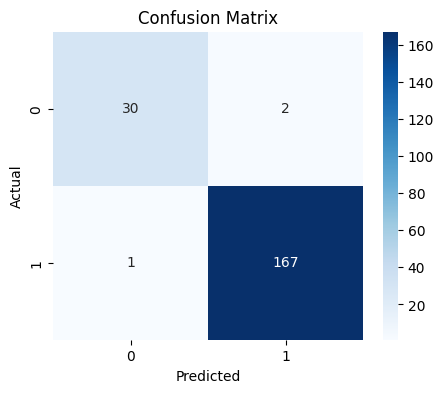

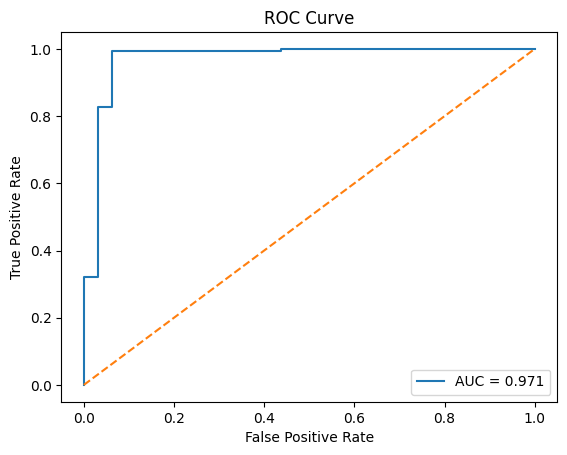

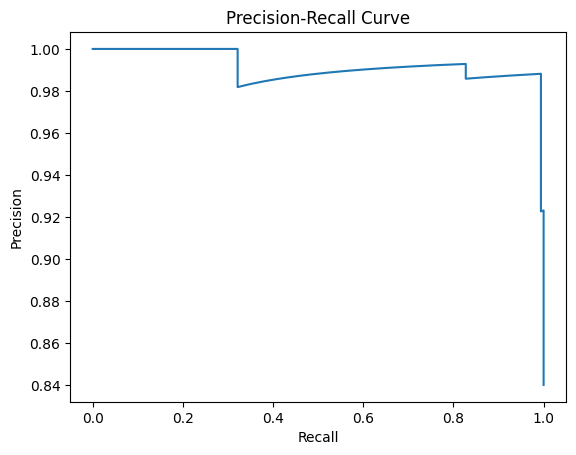

In [112]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# BASIC METRICS
# =========================
acc = accuracy_score(y_test, final_pred)
precision = precision_score(y_test, final_pred)
recall = recall_score(y_test, final_pred)
f1 = f1_score(y_test, final_pred)
auc = roc_auc_score(y_test, final_prob)

print(" FINAL MULTIMODAL RESULT")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC:", auc)

print("\nClassification Report:")
print(classification_report(y_test, final_pred))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(y_test, final_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# =========================
# PRECISION-RECALL CURVE (BONUS )
# =========================
precision_vals, recall_vals, _ = precision_recall_curve(y_test, final_prob)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()